In [2]:
# ============================================================
# Project: Automated Abstractive Text Summarization
# Model: Facebook BART Transformer
#
# Notebook 1: Dataset Exploration (EDA)
#
# Author: Oginni Adiguntoyin Wisdom
# ============================================================

In [3]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

print("✅ Libraries imported successfully!")

C:\Users\27355\Desktop\New folder\Data Science\Automated-Abstractive-Text-Summarization\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully!


In [5]:
from datasets import load_dataset

dataset = load_dataset("xsum")

print(dataset)



Trying to resume download...




Generating train split: 100%|██████████| 204045/204045 [00:02<00:00, 78812.12 examples/s]

Generating validation split: 100%|██████████| 11332/11332 [00:00<00:00, 82391.37 examples/s]

Generating test split: 100%|██████████| 11334/11334 [00:00<00:00, 99164.44 examples/s] 


DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 204045
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11332
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11334
    })
})


In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 204045
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11332
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11334
    })
})


In [7]:
print("Training samples:", len(dataset["train"]))
print("Validation samples:", len(dataset["validation"]))
print("Testing samples:", len(dataset["test"]))

Training samples: 204045
Validation samples: 11332
Testing samples: 11334


In [8]:
sample = dataset["train"][0]

print("DOCUMENT")
print("="*80)
print(sample["document"])

print("\n")
print("="*80)

print("REFERENCE SUMMARY")
print("="*80)
print(sample["summary"])

DOCUMENT
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.
Jeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.
However, she said more preventative work could have been carried out to ensure the retaining wall did not fail.
"It is difficult but I do think there is so much publicity for Dumfries and the Nith - and I totally appreciate that - but

In [9]:
train_df = dataset["train"].to_pandas()

train_df.head()

,document,summary,id
0,"The full cost of damage in Newton Stewart, one...",Clean-up operations are continuing across the ...,35232142
1,A fire alarm went off at the Holiday Inn in Ho...,Two tourist buses have been destroyed by fire ...,40143035
2,Ferrari appeared in a position to challenge un...,Lewis Hamilton stormed to pole position at the...,35951548
3,"John Edward Bates, formerly of Spalding, Linco...",A former Lincolnshire Police officer carried o...,36266422
4,Patients and staff were evacuated from Cerahpa...,An armed man who locked himself into a room at...,38826984


In [10]:
print(train_df.shape)

(204045, 3)


In [11]:
train_df.isnull().sum()

document    0
summary     0
id          0
dtype: int64

In [12]:
train_df["document_length"] = train_df["document"].apply(lambda x: len(x.split()))

train_df["summary_length"] = train_df["summary"].apply(lambda x: len(x.split()))

In [13]:
train_df[["document_length","summary_length"]].describe()

,document_length,summary_length
count,204045.000000,204045.000000
mean,373.864633,21.097645
std,304.632089,5.236819
min,0.000000,1.000000
25%,176.000000,18.000000
50%,295.000000,21.000000
75%,491.000000,24.000000
max,29189.000000,70.000000


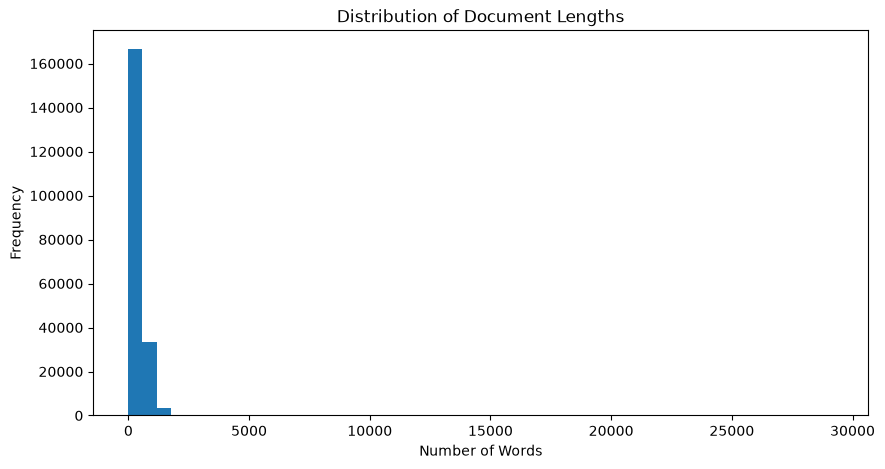

In [14]:
plt.figure(figsize=(10,5))

plt.hist(train_df["document_length"], bins=50)

plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

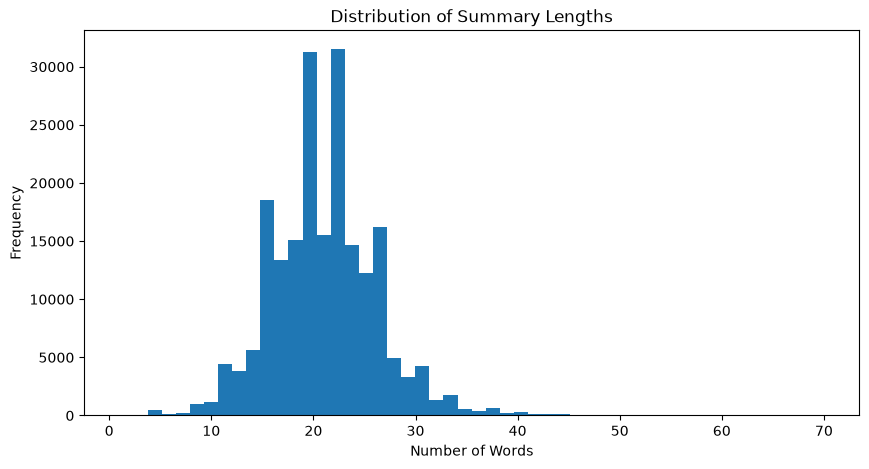

In [15]:
plt.figure(figsize=(10,5))

plt.hist(train_df["summary_length"], bins=50)

plt.title("Distribution of Summary Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [16]:
# ============================================================
# Display the First Five Samples
# ============================================================

train_df.head()

,document,summary,id,document_length,summary_length
0,"The full cost of damage in Newton Stewart, one...",Clean-up operations are continuing across the ...,35232142,400,18
1,A fire alarm went off at the Holiday Inn in Ho...,Two tourist buses have been destroyed by fire ...,40143035,155,17
2,Ferrari appeared in a position to challenge un...,Lewis Hamilton stormed to pole position at the...,35951548,887,17
3,"John Edward Bates, formerly of Spalding, Linco...",A former Lincolnshire Police officer carried o...,36266422,269,22
4,Patients and staff were evacuated from Cerahpa...,An armed man who locked himself into a room at...,38826984,171,25


In [17]:
train_df.sample(3)

,document,summary,id,document_length,summary_length
75028,Industrial output in the 18-nation eurozone fe...,The slow recovery of Europe's industrial secto...,26541363,248,20
124153,Inspectors who visited the hospital last month...,Bristol Children's Hospital has been told it n...,25494954,344,16
72934,Media playback is not supported on this device...,"West Brom boss Tony Pulis says ""life is too sh...",39453766,334,23


In [18]:
# ============================================================
# Calculate Text Lengths
# ============================================================

train_df["document_length"] = train_df["document"].apply(
    lambda x: len(x.split())
)

train_df["summary_length"] = train_df["summary"].apply(
    lambda x: len(x.split())
)

In [19]:
train_df[["document_length", "summary_length"]].describe()

,document_length,summary_length
count,204045.000000,204045.000000
mean,373.864633,21.097645
std,304.632089,5.236819
min,0.000000,1.000000
25%,176.000000,18.000000
50%,295.000000,21.000000
75%,491.000000,24.000000
max,29189.000000,70.000000


In [20]:
print(
    f"Average document length: {train_df['document_length'].mean():.2f} words"
)

print(
    f"Average summary length: {train_df['summary_length'].mean():.2f} words"
)

Average document length: 373.86 words
Average summary length: 21.10 words


In [21]:
longest = train_df.loc[
    train_df["document_length"].idxmax()
]

print("Longest document")

print("="*80)

print(longest["document"])

Longest document
As the presidency of Donald Trump approaches the six-month mark, find out which foreign leaders he has met or called since taking office, as well as the countries he has mentioned in his tweets.
Afghanistan has been near the top of every president's in-tray since US forces invaded the country in 2001. On the campaign trail, he repeatedly described the war in Afghanistan as a "disaster" and talked about pulling the remaining 10,000 or so US troops out of the country. But after a phone call with his Afghan counterpart Ashraf Ghani in December, officials in Kabul said President Trump had agreed to consider bolstering the US contingent there. The US has taken significant military action there in recent weeks and reportedly plans to send nearly 4,000 additional US troops, according to an AP report last month.On the 12 April, the US used the largest non-nuclear bomb ever deployed in combat, targeting a tunnel complex near Afghanistan's border with Pakistan that was said to h

In [22]:
longest_summary = train_df.loc[
    train_df["summary_length"].idxmax()
]

print(longest_summary["summary"])

"You'll find the airport has changed dramatically, you'll be able to book a taxi using an app on your phone, and you'll see a real spring in the step of many people in India now - people are charged with optimism," one Indian businessman said when I asked what had changed in the five years I'd been away from a city that, in many ways, had been my second home.


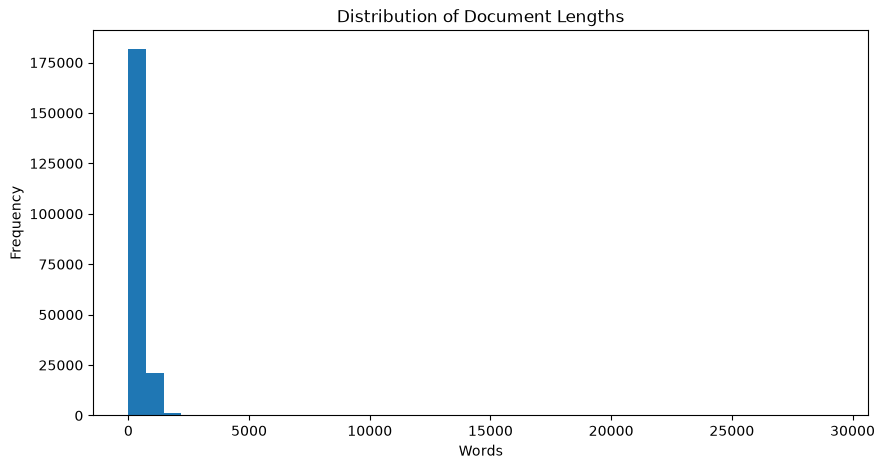

In [23]:
plt.figure(figsize=(10,5))

plt.hist(train_df["document_length"], bins=40)

plt.title("Distribution of Document Lengths")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

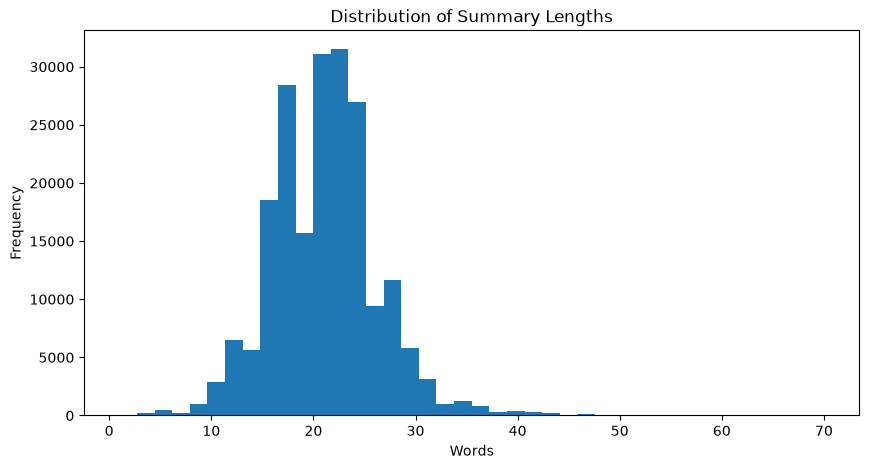

In [24]:
plt.figure(figsize=(10,5))

plt.hist(train_df["summary_length"], bins=40)

plt.title("Distribution of Summary Lengths")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

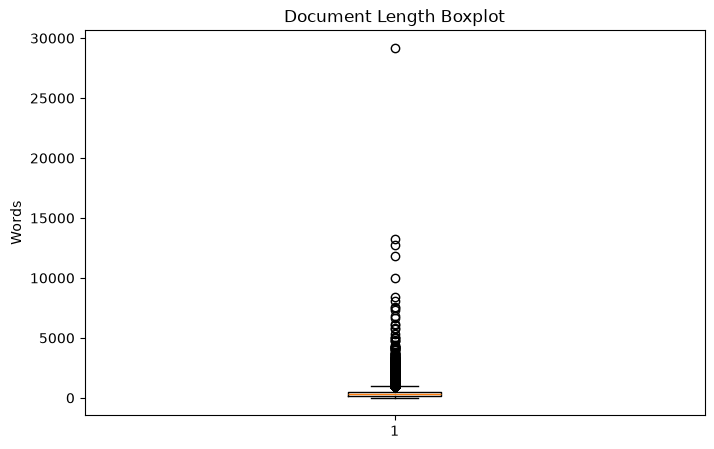

In [25]:
plt.figure(figsize=(8,5))

plt.boxplot(train_df["document_length"])

plt.title("Document Length Boxplot")

plt.ylabel("Words")

plt.show()

In [27]:
import os

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

sample_df.to_csv("data/xsum_sample.csv", index=False)

print("✅ Sample dataset saved successfully!")

✅ Sample dataset saved successfully!


In [1]:
print("Hello, BART Project!")

Hello, BART Project!
